---
title: "Introduction to single-cell ATAC-seq processing and RNA–ATAC integration with `SnapATAC2`"
author:
  - Maximilian Nuber
  - Junyan Lu
format:
  html:
    page-layout: full
    code-fold: false
    code-tools: true
    toc: true
    number-sections: true
    number-depth: 3
    # theme: book.scss
    embed-resources: true
execute:
  echo: true
  warning: false
  message: false
jupyter: python3
---

In this notebook, we analyze single-cell multiome data containing both gene expression and chromatin accessibility from the same cells. We first process RNA and ATAC separately, then integrate both modalities using SnapATAC2's spectral embedding framework.

By the end of this practical, you should be able to:

1. Explain how scATAC-seq data differs from scRNA-seq data.
2. Compute a low-dimensional embedding of chromatin accessibility data.
3. Compare RNA-only, ATAC-only, and joint RNA–ATAC embeddings.
4. Interpret how multi-modal integration changes cell-type separation.

## Why is scATAC-seq different from scRNA-seq?

Single-cell RNA-seq measures gene expression: each cell is represented by counts per gene.

Single-cell ATAC-seq measures chromatin accessibility: each cell is represented by fragments or counts in genomic regions. These regions may be fixed genomic bins, called peaks, or gene-associated accessibility scores.

This creates several challenges:

- The matrix is much larger because the genome is split into many regions.
- The data are very sparse because each cell captures only a fraction of accessible sites.
- Features are not directly genes, so annotation requires extra interpretation.
- Similarity between cells is often better captured by graph-based or region-based methods than by standard PCA alone.

### Question

Why might PCA on a raw cell-by-peak matrix be less suitable for scATAC-seq than PCA on a cell-by-gene RNA matrix?

Write down one technical reason and one biological reason.

In [1]:
import snapatac2 as snap
import scanpy as sc
import pandas as pd
import numpy as np

/home/rstudio/project/05_sc_atac_seq/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
snap.__version__

'2.9.0'

SnapATAC2 provides tutorials for standard scATAC-seq processing, RNA-guided annotation, and single-cell multiome analysis. In this notebook, we focus on the multiome case, where RNA and ATAC were measured in the same cells. 

In [3]:
rna = snap.read(
    snap.datasets.pbmc10k_multiome(modality="RNA"),
    backed=None,
)

atac = snap.read(
    snap.datasets.pbmc10k_multiome(modality="ATAC"),
    backed=None,
)

In [4]:
rna

AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'cell_type'
    var: 'gene_ids', 'feature_types'

In [5]:
atac

AnnData object with n_obs × n_vars = 9631 × 107194
    obs: 'domain', 'cell_type'
    var: 'feature_types'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap'

In [6]:
assert (rna.obs_names == atac.obs_names).all()

The RNA and ATAC objects contain the same cells. This is important because we are doing paired multiome integration: every cell has both gene expression and chromatin accessibility measurements.

## RNA-only embedding

We first analyze the gene expression modality alone. This gives us a reference point: how well can we separate cell types using RNA?

In [7]:
sc.pp.highly_variable_genes(
    rna,
    flavor="seurat_v3",
    n_top_genes=3000,
)

rna = rna[:, rna.var["highly_variable"]].copy()

In [8]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

In [9]:
snap.tl.spectral(rna, features=None)
snap.tl.umap(rna)

/home/rstudio/project/05_sc_atac_seq/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
fig = snap.pl.umap(
    rna,
    color="cell_type",
    interactive=False,
    show=False,
    height=600,
    width=600,
)
fig.show()
# fig.update_layout(
#     legend=dict(
#         orientation="v",
#         yanchor="top",
#         y=1,
#         xanchor="left",
#         x=1.02,
#     ),
#     margin=dict(r=250),
# )

# fig.show()

### Question

Which cell types are clearly separated in the RNA embedding? Which ones overlap?

## ATAC-only embedding

Next, we analyze chromatin accessibility alone. Here each feature is an accessible genomic region rather than a gene.

In [11]:
snap.tl.spectral(atac, features=None)
snap.tl.umap(atac)

/home/rstudio/project/05_sc_atac_seq/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-05-12 05:34:41 - INFO - Chromium init'ed with kwargs {}


2026-05-12 05:34:41 - INFO - Found chromium path: /root/.local/share/choreographer/deps/chrome-linux64/chrome
2026-05-12 05:34:41 - INFO - Temp directory created: /tmp/tmpy9xx6b71.
2026-05-12 05:34:41 - INFO - Opening browser.
2026-05-12 05:34:41 - INFO - Temp directory created: /tmp/tmprmafc96r.
2026-05-12 05:34:41 - INFO - Temporary directory at: /tmp/tmprmafc96r
2026-05-12 05:34:41 - INFO - Conforming 1 to file:///tmp/tmpy9xx6b71/index.html
2026-05-12 05:34:41 - INFO - Getting tab from queue (has 1)
2026-05-12 05:34:41 - INFO - Got 98A8
2026-05-12 05:34:42 - INFO - Reloading tab 98A8 before return.
2026-05-12 05:34:42 - INFO - Putting tab 98A8 back (queue size: 0).
2026-05-12 05:34:42 - INFO - Waiting for all cleanups to finish.
2026-05-12 05:34:42 - INFO - Exiting Kaleido.
2026-05-12 05:34:42 - INFO - TemporaryDirectory.cleanup() worked.
2026-05-12 05:34:42 - INFO - shutil.rmtree worked.
2026-05-12 05:34:42 - INFO - Closing browser.
2026-05-12 05:34:42 - INFO - TemporaryDirectory.c

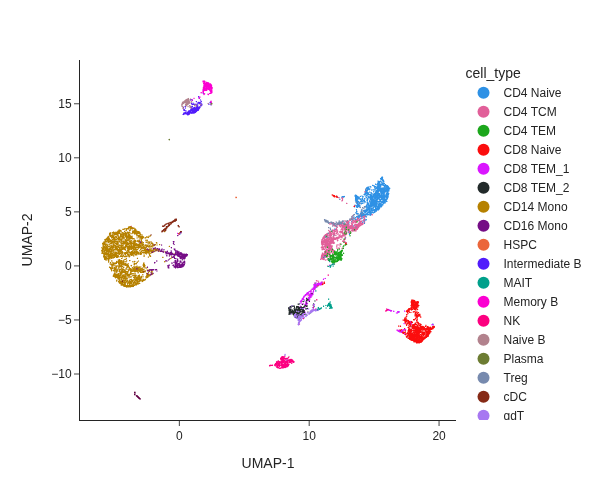

In [12]:
snap.pl.umap(
    atac,
    color="cell_type",
    interactive=False,
    height=500,
)

## What is spectral embedding?

In RNA workflows, we often use PCA to find directions of high variance.

In SnapATAC2, the main dimensionality reduction method is spectral embedding, also known as Laplacian Eigenmaps. Instead of asking which features explain the most variance, spectral embedding asks:

> Which low-dimensional representation preserves the similarity structure between cells?

Conceptually:

1. Start with a cell-by-feature matrix.
2. Define similarity between cells.
3. Build a graph-like representation of cell-cell similarity.
4. Compute eigenvectors of a graph Laplacian.
5. Use these eigenvectors as the low-dimensional embedding.

This is useful for sparse single-cell epigenomic data because the important structure is often neighborhood structure between cells, not only variance along individual features.

In SnapATAC2, the resulting embedding is stored in:

```python
adata.obsm["X_spectral"]
```

and the corresponding eigenvalues are stored in:

```python
adata.obsm["spectral_eigenvalue"]
```

This storage behavior is documented for `snapatac2.tl.spectral`.


In [13]:
atac.obsm["X_spectral"].shape

(9631, 30)

In [14]:
atac.uns["spectral_eigenvalue"][:10]

array([1.        , 0.23889138, 0.05674682, 0.04927427, 0.01752961,
       0.01229627, 0.00979847, 0.00671869, 0.00569738, 0.00513496])

2026-05-12 05:34:42 - INFO - Chromium init'ed with kwargs {}
2026-05-12 05:34:42 - INFO - Found chromium path: /root/.local/share/choreographer/deps/chrome-linux64/chrome
2026-05-12 05:34:42 - INFO - Temp directory created: /tmp/tmpedj06pwr.
2026-05-12 05:34:42 - INFO - Opening browser.
2026-05-12 05:34:42 - INFO - Temp directory created: /tmp/tmpjswnmt9w.
2026-05-12 05:34:42 - INFO - Temporary directory at: /tmp/tmpjswnmt9w


2026-05-12 05:34:42 - INFO - Conforming 1 to file:///tmp/tmpedj06pwr/index.html
2026-05-12 05:34:43 - INFO - Getting tab from queue (has 1)
2026-05-12 05:34:43 - INFO - Got 7671
2026-05-12 05:34:43 - INFO - Reloading tab 7671 before return.
2026-05-12 05:34:43 - INFO - Putting tab 7671 back (queue size: 0).
2026-05-12 05:34:43 - INFO - Waiting for all cleanups to finish.
2026-05-12 05:34:43 - INFO - Exiting Kaleido.
2026-05-12 05:34:43 - INFO - TemporaryDirectory.cleanup() worked.
2026-05-12 05:34:43 - INFO - shutil.rmtree worked.
2026-05-12 05:34:43 - INFO - Closing browser.
2026-05-12 05:34:43 - INFO - TemporaryDirectory.cleanup() worked.
2026-05-12 05:34:43 - INFO - shutil.rmtree worked.
2026-05-12 05:34:43 - INFO - Closing browser.
2026-05-12 05:34:43 - INFO - Cancelling tasks.
2026-05-12 05:34:43 - INFO - Exiting Kaleido/Choreo.
2026-05-12 05:34:43 - INFO - TemporaryDirectory.cleanup() worked.
2026-05-12 05:34:43 - INFO - shutil.rmtree worked.
2026-05-12 05:34:43 - INFO - Cancelli

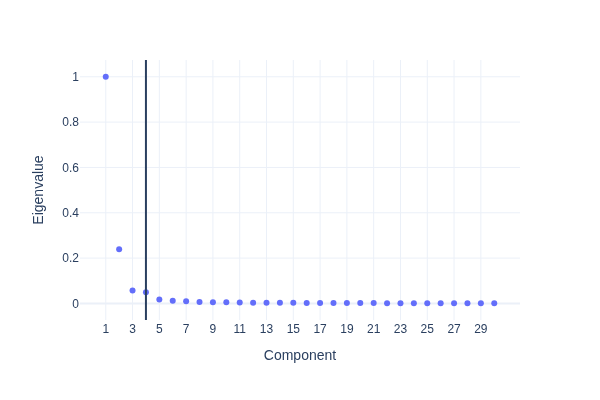

In [15]:
snap.pl.spectral_eigenvalues(atac, interactive=False)

## Joint RNA–ATAC embedding

So far, we have treated RNA and ATAC as separate views of the same cells.

Now we compute a joint embedding. The goal is to place cells close together when they are similar in both modalities.

SnapATAC2 provides `snap.tl.multi_spectral` for this purpose. In the official multiome tutorial, RNA and ATAC are processed separately and then passed together into `multi_spectral`; the resulting embedding is used as a joint latent space for UMAP visualization. :contentReference[oaicite:4]{index=4}

In [16]:
# First, we need to save the original ATAC UMAP for later:

atac.obsm["X_umap_atac"] = atac.obsm["X_umap"].copy()

In [18]:
embedding = snap.tl.multi_spectral(
    [rna, atac],
    features=None,
)[1]

2026-05-12 05:35:20 - INFO - Compute normalized views...


2026-05-12 05:36:00 - INFO - Compute embedding...


In [19]:
atac.obsm["X_joint"] = embedding

In [20]:
snap.tl.umap(
    atac,
    use_rep="X_joint",
)

/home/rstudio/project/05_sc_atac_seq/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-05-12 05:36:29 - INFO - TemporaryDirectory.cleanup() worked.
2026-05-12 05:36:29 - INFO - shutil.rmtree worked.


2026-05-12 05:36:29 - INFO - Chromium init'ed with kwargs {}
2026-05-12 05:36:29 - INFO - Found chromium path: /root/.local/share/choreographer/deps/chrome-linux64/chrome
2026-05-12 05:36:29 - INFO - Temp directory created: /tmp/tmpnq09o83g.
2026-05-12 05:36:29 - INFO - Opening browser.
2026-05-12 05:36:29 - INFO - Temp directory created: /tmp/tmpal0k3xyq.
2026-05-12 05:36:29 - INFO - Temporary directory at: /tmp/tmpal0k3xyq
2026-05-12 05:36:29 - INFO - Conforming 1 to file:///tmp/tmpnq09o83g/index.html
2026-05-12 05:36:30 - INFO - Getting tab from queue (has 1)
2026-05-12 05:36:30 - INFO - Got 9B0F
2026-05-12 05:36:30 - INFO - Reloading tab 9B0F before return.
2026-05-12 05:36:30 - INFO - Putting tab 9B0F back (queue size: 0).
2026-05-12 05:36:30 - INFO - Waiting for all cleanups to finish.
2026-05-12 05:36:30 - INFO - Exiting Kaleido.
2026-05-12 05:36:30 - INFO - TemporaryDirectory.cleanup() worked.
2026-05-12 05:36:30 - INFO - shutil.rmtree worked.
2026-05-12 05:36:30 - INFO - Closi

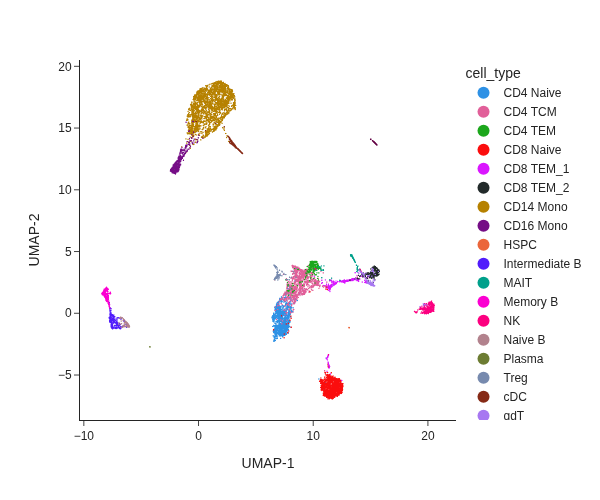

In [21]:
snap.pl.umap(
    atac,
    color="cell_type",
    interactive=False,
    height=500,
)

In [22]:
# save this explicitly as UMAP from the joint embedding:

atac.obsm["X_umap_joint"] = atac.obsm["X_umap"].copy()

## Comparing embeddings

We now compare three representations:

1. RNA-only spectral embedding
2. ATAC-only spectral embedding
3. Joint RNA–ATAC spectral embedding

The goal is not to declare one universally best embedding. Instead, we ask what biological structure each modality contributes.

In [23]:
# Store UMAP coordinates for comparison
rna_umap = pd.DataFrame(
    rna.obsm["X_umap"],
    index=rna.obs_names,
    columns=["RNA_UMAP1", "RNA_UMAP2"],
)

atac_umap = pd.DataFrame(
    atac.obsm["X_umap"],
    index=atac.obs_names,
    columns=["JOINT_UMAP1", "JOINT_UMAP2"],
)

Then plot both:

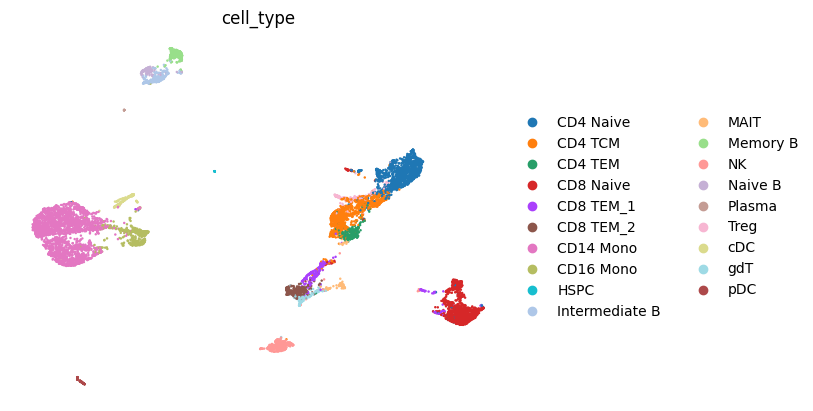

In [25]:
sc.pl.embedding(
    atac,
    basis="X_umap_atac",
    color = "cell_type",
    frameon=False,
)

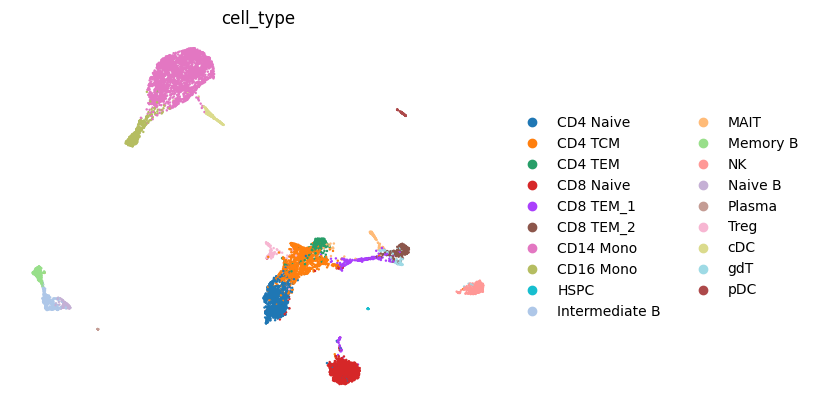

In [26]:
sc.pl.embedding(
    atac,
    basis="X_umap_joint",
    color = "cell_type",
    frameon=False,
)

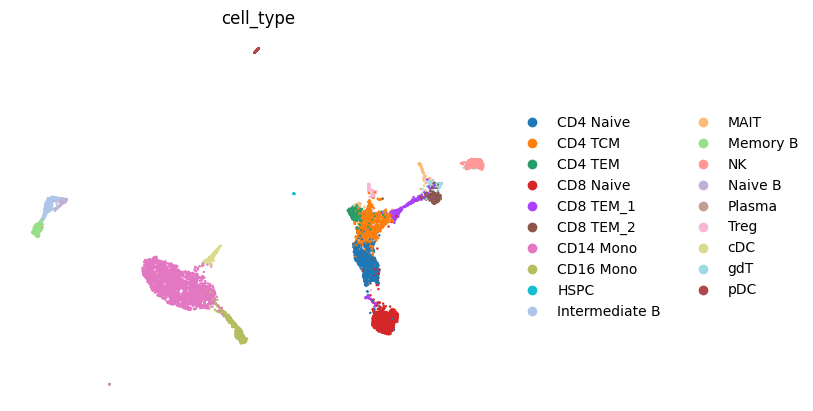

In [27]:
sc.pl.embedding(
    rna,
    basis="X_umap",
    color = "cell_type",
    frameon=False,
)

### Question

Look at the RNA-only, ATAC-only, and joint embeddings.

1. Which embedding gives the clearest broad cell-type separation?
2. Which embedding best separates closely related immune populations?
3. Why might the joint embedding be more stable than either modality alone?

## Clustering the joint representation

Once we have a joint embedding, we can build neighborhoods and cluster cells based on the integrated representation.

In [28]:
snap.pp.knn(
    atac,
    use_rep="X_joint",
)

snap.tl.leiden(
    atac,
    resolution=1.0,
)

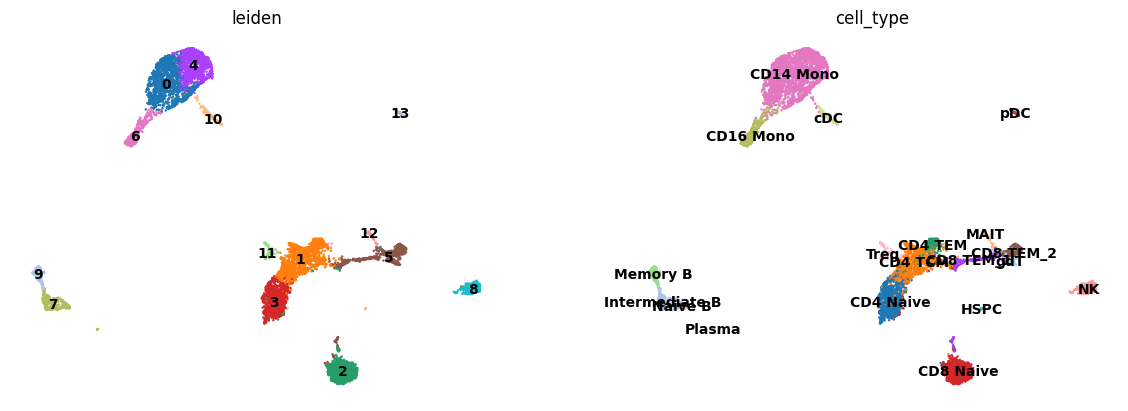

In [32]:
sc.pl.embedding(
    atac,
    basis="X_umap_joint",
    color=["leiden", "cell_type"],
    frameon=False,
    legend_loc="on data",
)

### Question

Do the Leiden clusters correspond to annotated cell types? Where do clusters split a known cell type into subpopulations?

## Interpretation

RNA and ATAC measure different aspects of cell identity.

RNA tells us which genes are currently expressed. ATAC tells us which regulatory regions are accessible and therefore potentially active or primed.

The joint embedding combines both views. This can help when:

- RNA separates some populations poorly but chromatin accessibility differs.
- ATAC is sparse, but RNA helps stabilize the neighborhood structure.
- We want clusters that reflect both expression state and regulatory state.

However, integration is not magic. If one modality is much lower quality, or if the modalities contain conflicting biological signals, the joint embedding can also obscure modality-specific structure.

## Final exercise

Choose one immune cell type that appears in the annotation.

1. Inspect where it lies in the RNA-only embedding.
2. Inspect where it lies in the ATAC-only embedding.
3. Inspect where it lies in the joint embedding.
4. Decide whether RNA, ATAC, or joint integration gives the clearest representation for this cell type.

Write 3–5 sentences explaining your conclusion.